In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [88]:
df = pd.read_csv("mushrooms.csv")

**Some information about dataset**

In [89]:
df = pd.DataFrame(df)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [91]:
df.shape


(8124, 23)

In [92]:
(2480/8124)*100


30.526834071885773

In [93]:
df.nunique()

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

In [94]:
for column in df.columns:
    print(column, ": ", df[column].unique())

class :  <ArrowStringArray>
['p', 'e']
Length: 2, dtype: str
cap-shape :  <ArrowStringArray>
['x', 'b', 's', 'f', 'k', 'c']
Length: 6, dtype: str
cap-surface :  <ArrowStringArray>
['s', 'y', 'f', 'g']
Length: 4, dtype: str
cap-color :  <ArrowStringArray>
['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']
Length: 10, dtype: str
bruises :  <ArrowStringArray>
['t', 'f']
Length: 2, dtype: str
odor :  <ArrowStringArray>
['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 9, dtype: str
gill-attachment :  <ArrowStringArray>
['f', 'a']
Length: 2, dtype: str
gill-spacing :  <ArrowStringArray>
['c', 'w']
Length: 2, dtype: str
gill-size :  <ArrowStringArray>
['n', 'b']
Length: 2, dtype: str
gill-color :  <ArrowStringArray>
['k', 'n', 'g', 'p', 'w', 'h', 'u', 'e', 'b', 'r', 'y', 'o']
Length: 12, dtype: str
stalk-shape :  <ArrowStringArray>
['e', 't']
Length: 2, dtype: str
stalk-root :  <ArrowStringArray>
['e', 'c', 'b', 'r', '?']
Length: 5, dtype: str
stalk-surface-above-ring :  <ArrowStringArra

**Checking for null values and duplicates**

In [95]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [96]:
(df == "?").sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [97]:
(df == "Nan").sum()


class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [98]:
df.duplicated().sum()

np.int64(0)

See if the data is balanced

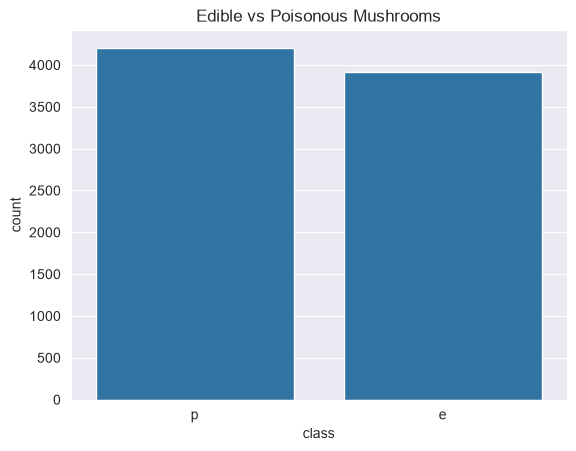

In [99]:
x = df["class"].unique()
y = df["class"].value_counts()
sns.barplot( x=x, y=y)
plt.xlabel("class")
plt.ylabel("count")
plt.title("Edible vs Poisonous Mushrooms")
plt.show()

**Separate X and Y**

In [100]:
y = df["class"]
X = df.drop("class", axis=1)

**Encode output**

In [101]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [102]:
le.classes_

array(['e', 'p'], dtype=object)

0 is edible, 1 is poisonous

**Encode the categorical features**

In [107]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore",
                     sparse_output=False)
X = encoder.fit_transform(X)

**Train-test split**

In [104]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    stratify=y,
                                                    test_size=0.3,
                                                    shuffle=True)


In [105]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Save everything**

In [110]:
import joblib
processed_data = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
    "scaler": scaler,
    "encoder": encoder,
    "le": le
}
joblib.dump(processed_data, "processed_data.joblib")

['processed_data.joblib']